In [86]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json

n_ticks = 5
linestyles = ['-', '--', ':', '-.', (0, (5, 10)), (0, (5, 1)), (0, (1, 10)), 
          (0, (1, 1)), (0, (3, 5, 1, 5)), (0, (7, 2, 1, 2))]
colors = ["darkgreen", "red", "orange", "blue"]

In [87]:
result_path = Path("../results/mrs_analysis")
bias_types = ["less_positive_class"]
less_bias_strengths = ["0.1"]
weight_types = ["mrs_step", "random"]
# datasets = ["gbs_allensbach"]
datasets = ["folktables_income"]

save_path = Path("diagrams/mrs_analysis")
save_path = save_path / datasets[0] / bias_types[0]
save_path.mkdir(exist_ok=True, parents=True)

In [88]:
dict_list = []

for dataset in datasets:
    for bias_type in bias_types:
        bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            for weight_type in weight_types:
                mrs_analysis_file_name = result_path / weight_type / dataset / bias_type /\
                        bias_strength / "mrs" 
                mrs_analysis_mmd = pd.read_json(str(mrs_analysis_file_name / "mmds/mmds.json"), 
                                                        orient="columns", typ="frame", convert_axes=False)

                mrs_analysis_relative_bias = pd.read_json(str(mrs_analysis_file_name / "relative_bias/relative_biases.json"), 
                                                        orient="columns", typ="frame", convert_axes=False)
                mrs_analysis_auroc = pd.read_json(str(mrs_analysis_file_name / "aurocs/aurocs.json"), 
                                                        orient="columns", typ="frame", convert_axes=False)
                mrs_analysis_wasserstein = pd.read_json(str(mrs_analysis_file_name / "wassersteins/wassersteins.json"), 
                                                        orient="columns", typ="frame", convert_axes=False)
                dict_list.append(
                    {
                        "Data Set": dataset,
                        "Function": weight_type,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                        "MMD": mrs_analysis_mmd,
                        "Relative Bias": mrs_analysis_relative_bias,
                        "AUROC": mrs_analysis_auroc,
                        "Wasserstein": mrs_analysis_wasserstein,
                    }
                                )
result_df = pd.DataFrame(data=dict_list)

In [89]:
with open(mrs_analysis_file_name / "metadata.json") as file:
    metadata = json.load(file)

In [90]:
random_mmd = result_df.iloc[1]["MMD"]["0.0"]
random_relative_bias = result_df.iloc[1]["Relative Bias"]["0.0"]
random_auroc = result_df.iloc[1]["AUROC"]["0.0"]
random_wasserstein= result_df.iloc[1]["Wasserstein"]["0.0"]

random_mmd = np.concatenate(random_mmd).reshape(len(random_mmd),*np.shape(random_mmd[0]))
random_relative_bias = np.concatenate(random_relative_bias).reshape(len(random_relative_bias),*np.shape(random_relative_bias[0]))
random_auroc = np.concatenate(random_auroc).reshape(len(random_auroc),*np.shape(random_auroc[0]))
random_wasserstein = np.concatenate(random_wasserstein).reshape(len(random_wasserstein),*np.shape(random_wasserstein[0]))

In [91]:
for dataset in datasets:
    for bias_type in bias_types:
        bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            mrs_step_mmd = result_df.loc[(result_df["Function"]=="mrs_step") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["MMD"].values[0]
            mrs_step_relative_bias = result_df.loc[(result_df["Function"]=="mrs_step") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["Relative Bias"].values[0]
            mrs_step_aurocs = result_df.loc[(result_df["Function"]=="mrs_step") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["AUROC"].values[0]
            mrs_step_wassersteins = result_df.loc[(result_df["Function"]=="mrs_step") & (result_df["bias_type"]==bias_type) & 
                                                    (result_df["bias_strength"]==bias_strength) & 
                                                    (result_df["Data Set"]==dataset)]["Wasserstein"].values[0]

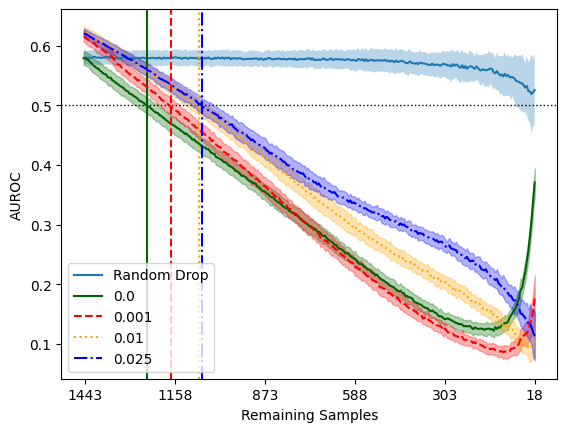

In [92]:
mrs_iteration_list = []
auroc_dicts = result_df.iloc[0]["AUROC"]
mean_random_auroc = np.mean(random_auroc, axis=0)
std_random_auroc = np.std(random_auroc, axis=0)
min_length = np.min(
        [
            [len(auroc_list) for auroc_list in auroc_dicts[key].values]
            for key in auroc_dicts.to_dict().keys()
        ]
    )
x_labels = list(range(metadata["number_of_samples"], 0, -metadata["n_dropped"]))[:min_length]
sns.lineplot(x=x_labels, y=mean_random_auroc, label="Random Drop").set(xlabel="Remaining Samples", ylabel="AUROC")
plt.fill_between(x=x_labels, y1=mean_random_auroc + std_random_auroc, 
                 y2=mean_random_auroc - std_random_auroc, alpha=0.3)
plt.axhline(y=0.5, color="black", linestyle="dotted", linewidth=1) 
for i, hyperparameter in enumerate(auroc_dicts.to_dict().keys()):
    dictionary = auroc_dicts.to_dict()[hyperparameter]
    auroc_list = np.array(list(dictionary.values()))[:,:min_length]

    mean = np.mean(auroc_list, axis=0)
    for j, value in enumerate(mean):
        if value < 0.5:
            mrs_iteration = j
            break
    mrs_iteration_list.append(mrs_iteration)
    plt.axvline(metadata["number_of_samples"] - mrs_iteration * metadata["n_dropped"], linestyle=linestyles[i], color=colors[i])
    std = np.std(auroc_list, axis=0)
    auroc_upper = mean + std
    auroc_lower = np.maximum(mean - std, 0)
    sns.lineplot(x=x_labels, y=mean, label=str(hyperparameter), linestyle=linestyles[i], color=colors[i])
    plt.fill_between(x=x_labels, y1=auroc_lower, y2=auroc_upper, alpha=0.3, color=colors[i])

step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(save_path / "auroc.pdf", pad_inches=0, bbox_inches="tight")

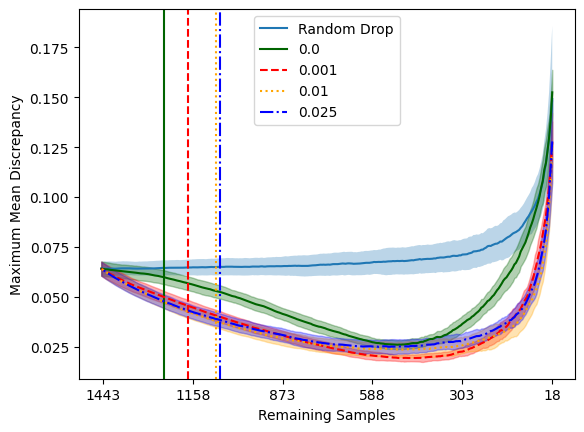

In [93]:
mmd_dicts = result_df.iloc[0]["MMD"]
mean_random_mmd = np.mean(random_mmd, axis=0)
std_random_mmd = np.std(random_mmd, axis=0)
min_length = np.min(
        [
            [len(mmd_list) for mmd_list in mmd_dicts[key].values]
            for key in mmd_dicts.to_dict().keys()
        ]
    )
x_labels = list(range(metadata["number_of_samples"], 0, -metadata["n_dropped"]))[:min_length]
sns.lineplot(x=x_labels, y=mean_random_mmd, label="Random Drop").set(xlabel="Remaining Samples", ylabel="Maximum Mean Discrepancy")
plt.fill_between(x=x_labels, y1=mean_random_mmd + std_random_mmd, 
                 y2=mean_random_mmd - std_random_mmd, alpha=0.3)
for i, hyperparameter in enumerate(mmd_dicts.to_dict().keys()):
    dictionary = mmd_dicts.to_dict()[hyperparameter]
    mmd_list = np.array(list(dictionary.values()))[:,:min_length]
    plt.axvline(metadata["number_of_samples"] - mrs_iteration_list[i] * metadata["n_dropped"], linestyle=linestyles[i], color=colors[i])
    mean = np.mean(mmd_list, axis=0)
    std = np.std(mmd_list, axis=0)
    mmds_upper = mean + std
    mmds_lower = np.maximum(mean - std, 0)
    sns.lineplot(x=x_labels, y=mean, label=str(hyperparameter), linestyle=linestyles[i], color=colors[i])
    plt.fill_between(x=x_labels, y1=mmds_lower, y2=mmds_upper, alpha=0.3, color=colors[i])

step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(save_path / "mmds.pdf", pad_inches=0, bbox_inches="tight")

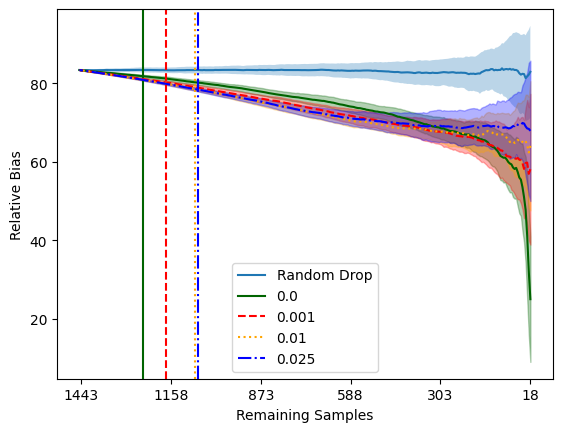

In [94]:
relative_bias_dicts = result_df.iloc[0]["Relative Bias"]
mean_random_relative_bias = np.mean(random_relative_bias, axis=0)
std_random_relative_bias = np.std(random_relative_bias, axis=0)
min_length = np.min(
        [
            [len(relative_bias_list) for relative_bias_list in relative_bias_dicts[key].values]
            for key in relative_bias_dicts.to_dict().keys()
        ]
    )
x_labels = list(range(metadata["number_of_samples"], 0, -metadata["n_dropped"]))[:min_length]
sns.lineplot(x=x_labels, y=mean_random_relative_bias, label="Random Drop").set(xlabel="Remaining Samples", ylabel="Relative Bias")
plt.fill_between(x=x_labels, y1=mean_random_relative_bias + std_random_relative_bias, 
                 y2=mean_random_relative_bias - std_random_relative_bias, alpha=0.3)
for i, hyperparameter in enumerate(relative_bias_dicts.to_dict().keys()):
    dictionary = relative_bias_dicts.to_dict()[hyperparameter]
    relative_bias_list = np.array(list(dictionary.values()))[:,:min_length]
    plt.axvline(metadata["number_of_samples"] - mrs_iteration_list[i] * metadata["n_dropped"], linestyle=linestyles[i], color=colors[i])
    mean = np.mean(relative_bias_list, axis=0)
    std = np.std(relative_bias_list, axis=0)
    relative_bias_upper = mean + std
    relative_bias_lower = np.maximum(mean - std, 0)
    sns.lineplot(x=x_labels, y=mean, label=str(hyperparameter), linestyle=linestyles[i], color=colors[i])
    plt.fill_between(x=x_labels, y1=relative_bias_lower, y2=relative_bias_upper, alpha=0.3, color=colors[i])

step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(save_path / "relative_bias.pdf", pad_inches=0, bbox_inches="tight")

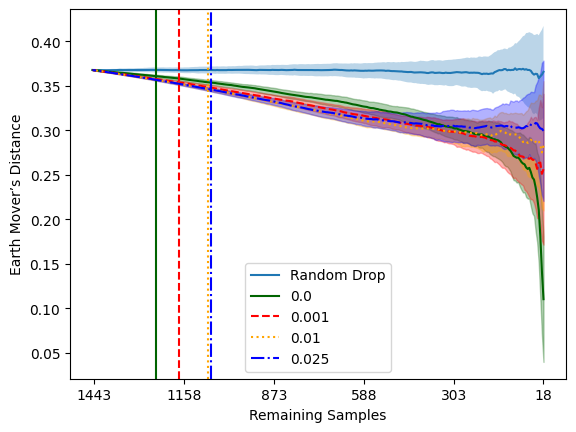

In [95]:
wasserstein_dicts = result_df.iloc[0]["Wasserstein"]
mean_random_wasserstein = np.mean(random_wasserstein, axis=0)
std_random_wasserstein = np.std(random_wasserstein, axis=0)
min_length = np.min(
        [
            [len(wasserstein_list) for wasserstein_list in wasserstein_dicts[key].values]
            for key in wasserstein_dicts.to_dict().keys()
        ]
    )
x_labels = list(range(metadata["number_of_samples"], 0, -metadata["n_dropped"]))[:min_length]
sns.lineplot(x=x_labels, y=mean_random_wasserstein, label="Random Drop").set(xlabel="Remaining Samples", ylabel="Earth Mover’s Distance")
plt.fill_between(x=x_labels, y1=mean_random_wasserstein + std_random_wasserstein, 
                 y2=mean_random_wasserstein - std_random_wasserstein, alpha=0.3)
for i, hyperparameter in enumerate(wasserstein_dicts.to_dict().keys()):
    dictionary = wasserstein_dicts.to_dict()[hyperparameter]
    wasserstein_list = np.array(list(dictionary.values()))[:,:min_length]
    plt.axvline(metadata["number_of_samples"] - mrs_iteration_list[i] * metadata["n_dropped"], linestyle=linestyles[i], color=colors[i])
    mean = np.mean(wasserstein_list, axis=0)
    std = np.std(wasserstein_list, axis=0)
    wasserstein_upper = mean + std
    wasserstein_lower = np.maximum(mean - std, 0)
    sns.lineplot(x=x_labels, y=mean, label=str(hyperparameter), linestyle=linestyles[i], color=colors[i])
    plt.fill_between(x=x_labels, y1=wasserstein_lower, y2=wasserstein_upper, alpha=0.3, color=colors[i])

step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(save_path / "wasserstein.pdf", pad_inches=0, bbox_inches="tight")

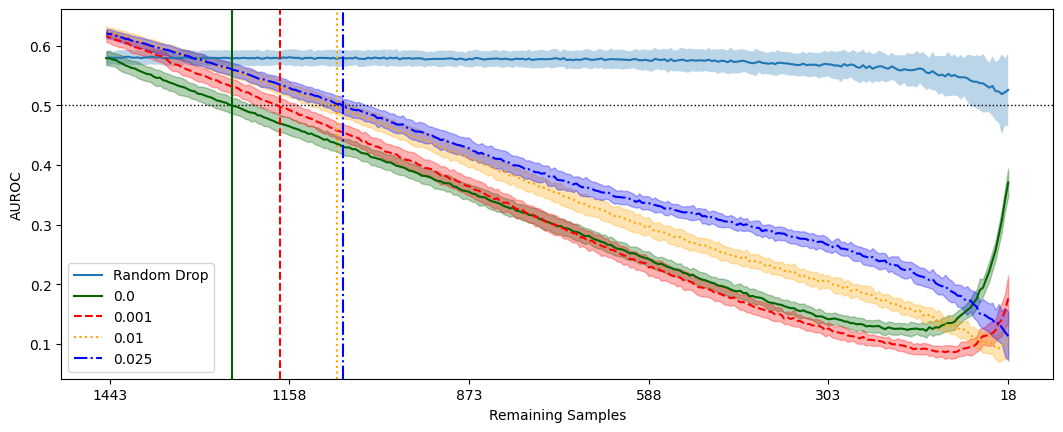

In [96]:
plt.figure(figsize=(12.8, 4.8))
min_length = np.min(
        [
            [len(auroc_list) for auroc_list in auroc_dicts[key].values]
            for key in auroc_dicts.to_dict().keys()
        ]
    )
x_labels = list(range(metadata["number_of_samples"], 0, -metadata["n_dropped"]))[:min_length]
sns.lineplot(x=x_labels, y=mean_random_auroc, label="Random Drop").set(xlabel="Remaining Samples", ylabel="AUROC")
plt.fill_between(x=x_labels, y1=mean_random_auroc + std_random_auroc, 
                 y2=mean_random_auroc - std_random_auroc, alpha=0.3)
plt.axhline(y=0.5, color="black", linestyle="dotted", linewidth=1) 
for i, hyperparameter in enumerate(auroc_dicts.to_dict().keys()):
    dictionary = auroc_dicts.to_dict()[hyperparameter]
    auroc_list = np.array(list(dictionary.values()))[:,:min_length]
    plt.axvline(metadata["number_of_samples"] - mrs_iteration_list[i] * metadata["n_dropped"], linestyle=linestyles[i], color=colors[i])
    mean = np.mean(auroc_list, axis=0)
    std = np.std(auroc_list, axis=0)
    auroc_upper = mean + std
    auroc_lower = np.maximum(mean - std, 0)
    sns.lineplot(x=x_labels, y=mean, label=str(hyperparameter), linestyle=linestyles[i], color=colors[i])
    plt.fill_between(x=x_labels, y1=auroc_lower, y2=auroc_upper, alpha=0.3, color=colors[i])

step_size = len(x_labels) // n_ticks
x_ticks = x_labels[::-step_size]
plt.xticks(x_ticks)
plt.gca().invert_xaxis()

plt.savefig(save_path / "auroc_wide.pdf", pad_inches=0, bbox_inches="tight")